In [3]:
import sys
sys.path.append("..")

from src.dataset import *
import pandas as pd
import numpy as np
from typing import Dict, Optional

import matplotlib.pyplot as plt
import seaborn as sns

# sns.set_style("darkgrid")

%matplotlib inline

# Compatibility wrapper to match prior notebook usage with current src API
class DatasetSandbox:
    def __init__(self):
        self.generator = DatasetGenerator()
        self.data: Optional[pd.DataFrame] = None
        # Default column names used by src.dataset synthetic generator
        self.protected_attribute: str = "protected_attribute"
        self.target_column: str = "target"
    
    def load_or_generate_dataset(
        self,
        dataset_type: str,
        dataset_name: Optional[str] = None,
        n_samples: Optional[int] = None,
        feature_specs: Optional[Dict[str, Dict]] = None,
        protected_attr_ratio: float = 0.5,
        positive_label_ratio: float = 0.5,
    ) -> pd.DataFrame:
        if dataset_type == "benchmark":
            if not dataset_name:
                raise ValueError("dataset_name is required for benchmark datasets")
            self.data = self.generator.load_benchmark_dataset(dataset_name)
            # Use the protected attribute set by the loader (e.g., "sex" for Adult)
            if hasattr(self.generator, "protected_attribute") and self.generator.protected_attribute:
                self.protected_attribute = self.generator.protected_attribute
            return self.data
        elif dataset_type == "synthetic":
            if n_samples is None or feature_specs is None:
                raise ValueError("n_samples and feature_specs are required for synthetic datasets")
            self.data = self.generator.generate_synthetic_dataset(
                n_samples=n_samples,
                feature_specs=feature_specs,
                protected_attr_ratio=protected_attr_ratio,
                positive_label_ratio=positive_label_ratio,
            )
            # Synthetic generator uses the default names set in __init__
            return self.data
        else:
            raise ValueError(f"Unknown dataset_type: {dataset_type}")
    
    def inject_bias(self, bias_type: BiasType, **kwargs) -> pd.DataFrame:
        if self.data is None:
            raise ValueError("Load or generate data before injecting bias")
        if bias_type == BiasType.REPRESENTATION:
            transformer = RepresentationBias(
                protected_attribute=self.protected_attribute,
                underrepresented_group=kwargs["underrepresented_group"],
                reduction_factor=kwargs["reduction_factor"],
            )
        elif bias_type == BiasType.MEASUREMENT:
            transformer = MeasurementBias(
                feature=kwargs["feature"],
                protected_attribute=self.protected_attribute,
                affected_group=kwargs["affected_group"],
                noise_std=kwargs["noise_std"],
            )
        elif bias_type == BiasType.SAMPLING:
            transformer = SamplingBias(
                protected_attribute=self.protected_attribute,
                target_column=self.target_column,
                affected_group=kwargs["affected_group"],
                label_value=kwargs["label_value"],
                sampling_rate=kwargs["sampling_rate"],
            )
        elif bias_type == BiasType.LABEL:
            transformer = LabelBias(
                protected_attribute=self.protected_attribute,
                target_column=self.target_column,
                affected_group=kwargs["affected_group"],
                flip_probability=kwargs["flip_probability"],
            )
        else:
            raise ValueError(f"Unsupported bias_type: {bias_type}")
        self.data = transformer.transform(self.data)
        return self.data

In [4]:
data_sandbox = DatasetSandbox()
df = data_sandbox.load_or_generate_dataset(dataset_type="benchmark", dataset_name="adult")

In [5]:
df.shape

(48842, 15)

In [6]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,0,0,0,30,United-States,<=50K


In [7]:
# Seed randomness for reproducibility in tests
np.random.seed(42)

# Initialize the sandbox
sandbox = DatasetSandbox()

# Generate a synthetic dataset
feature_specs = {
    "income": {
        "type": FeatureType.NUMERIC,
        "params": {"distribution": "normal", "mean": 50000, "std": 20000}
    },
    "education": {
        "type": FeatureType.CATEGORICAL,
        "params": {
            "categories": ["high_school", "bachelors", "masters"],
            "probabilities": [0.4, 0.4, 0.2]
        }
    }
}

data = sandbox.load_or_generate_dataset(
    dataset_type="synthetic",
    n_samples=2000,
    feature_specs=feature_specs,
    protected_attr_ratio=0.5,
    positive_label_ratio=0.6,
)

# Inject representation bias
biased_data = sandbox.inject_bias(
    bias_type=BiasType.REPRESENTATION,
    underrepresented_group=1,
    reduction_factor=0.5
)

In [8]:
data.head()

,protected_attribute,income,education,target
0,0,32440.348265,bachelors,1
1,1,33462.392919,bachelors,1
2,1,45470.422162,high_school,1
3,1,57347.310136,high_school,1
4,0,68271.692525,bachelors,1


In [9]:
data.shape

(2000, 4)

In [10]:
def create_synthetic_dataset():
    """
    Create a synthetic dataset with realistic features for a job application scenario
    """
    # Seed for reproducibility
    np.random.seed(123)
    # Initialize the sandbox
    sandbox = DatasetSandbox()
    
    # Define feature specifications
    feature_specs = {
        "age": {
            "type": FeatureType.NUMERIC,
            "params": {
                "distribution": "normal",
                "mean": 35,
                "std": 10
            }
        },
        "years_experience": {
            "type": FeatureType.NUMERIC,
            "params": {
                "distribution": "normal",
                "mean": 8,
                "std": 5
            }
        },
        "education_level": {
            "type": FeatureType.CATEGORICAL,
            "params": {
                "categories": ["high_school", "bachelors", "masters", "phd"],
                "probabilities": [0.3, 0.4, 0.2, 0.1]
            }
        }
    }
    
    # Generate base dataset
    data = sandbox.load_or_generate_dataset(
        dataset_type="synthetic",
        n_samples=10000,
        feature_specs=feature_specs,
        protected_attr_ratio=0.5,  # 50-50 split between protected groups
        positive_label_ratio=0.6   # 60% positive labels (hired)
    )
    
    return sandbox

def demonstrate_bias_injection():
    """
    Demonstrate different types of bias injection and their effects
    """
    # Create base dataset
    sandbox = create_synthetic_dataset()
    original_data = sandbox.data.copy()
    
    results = {}
    results['original'] = original_data.copy()
    
    # 1. Representation Bias
    print("\n=== Demonstrating Representation Bias ===")
    sandbox.data = original_data.copy()
    results['representation_bias'] = sandbox.inject_bias(
        bias_type=BiasType.REPRESENTATION,
        underrepresented_group=1,
        reduction_factor=0.3
    )
    
    print("Original protected group distribution:")
    print(original_data['protected_attribute'].value_counts(normalize=True))
    print("\nBiased protected group distribution:")
    print(results['representation_bias']['protected_attribute'].value_counts(normalize=True))
    
    # 2. Measurement Bias
    print("\n=== Demonstrating Measurement Bias ===")
    sandbox.data = original_data.copy()
    results['measurement_bias'] = sandbox.inject_bias(
        bias_type=BiasType.MEASUREMENT,
        feature="years_experience",
        affected_group=1,
        noise_std=5.0
    )
    
    # 3. Sampling Bias
    print("\n=== Demonstrating Sampling Bias ===")
    sandbox.data = original_data.copy()
    results['sampling_bias'] = sandbox.inject_bias(
        bias_type=BiasType.SAMPLING,
        affected_group=1,
        label_value=1,
        sampling_rate=0.5
    )
    
    # 4. Label Bias
    print("\n=== Demonstrating Label Bias ===")
    sandbox.data = original_data.copy()
    results['label_bias'] = sandbox.inject_bias(
        bias_type=BiasType.LABEL,
        affected_group=1,
        flip_probability=0.2
    )
    
    return results

def visualize_bias_effects(data_dict):
    """
    Create visualizations to show the effects of different types of bias
    """
    # Set default style
    plt.style.use('default')
    
    # Create figure for all visualizations
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Representation Bias
    plt.subplot(3, 2, 1)
    counts = data_dict['original']['protected_attribute'].value_counts()
    plt.bar(counts.index, counts.values)
    plt.title('Original Protected Group Distribution')
    plt.xlabel('Protected Attribute')
    plt.ylabel('Count')
    
    plt.subplot(3, 2, 2)
    counts = data_dict['representation_bias']['protected_attribute'].value_counts()
    plt.bar(counts.index, counts.values)
    plt.title('After Representation Bias')
    plt.xlabel('Protected Attribute')
    plt.ylabel('Count')
    
    # 2. Measurement Bias
    plt.subplot(3, 2, 3)
    box_data = [
        data_dict['original'][data_dict['original']['protected_attribute'] == i]['years_experience']
        for i in [0, 1]
    ]
    plt.boxplot(box_data, tick_labels=['Group 0', 'Group 1'])
    plt.title('Original Years Experience Distribution')
    plt.ylabel('Years of Experience')
    
    plt.subplot(3, 2, 4)
    box_data = [
        data_dict['measurement_bias'][data_dict['measurement_bias']['protected_attribute'] == i]['years_experience']
        for i in [0, 1]
    ]
    plt.boxplot(box_data, tick_labels=['Group 0', 'Group 1'])
    plt.title('After Measurement Bias')
    plt.ylabel('Years of Experience')
    
    # 3. Label Distribution
    plt.subplot(3, 2, 5)
    crosstab = pd.crosstab(
        data_dict['original']['protected_attribute'],
        data_dict['original']['target'],
        normalize='index'
    )
    plt.imshow(crosstab, cmap='YlOrRd', aspect='auto')
    plt.colorbar()
    plt.xticks([0, 1], ['Negative', 'Positive'])
    plt.yticks([0, 1], ['Group 0', 'Group 1'])
    plt.title('Original Label Distribution')
    
    plt.subplot(3, 2, 6)
    crosstab = pd.crosstab(
        data_dict['label_bias']['protected_attribute'],
        data_dict['label_bias']['target'],
        normalize='index'
    )
    plt.imshow(crosstab, cmap='YlOrRd', aspect='auto')
    plt.colorbar()
    plt.xticks([0, 1], ['Negative', 'Positive'])
    plt.yticks([0, 1], ['Group 0', 'Group 1'])
    plt.title('After Label Bias')
    
    plt.tight_layout()
    return plt

In [11]:
# Generate datasets and inject different types of bias
biased_datasets = demonstrate_bias_injection()


=== Demonstrating Representation Bias ===
Original protected group distribution:
protected_attribute
1    0.5035
0    0.4965
Name: proportion, dtype: float64

Biased protected group distribution:
protected_attribute
0    0.766677
1    0.233323
Name: proportion, dtype: float64

=== Demonstrating Measurement Bias ===

=== Demonstrating Sampling Bias ===

=== Demonstrating Label Bias ===


In [12]:
# Programmatic checks validating bias injections

# Use the previously generated datasets 'biased_datasets'
orig = biased_datasets['original']
rep = biased_datasets['representation_bias']
meas = biased_datasets['measurement_bias']
samp = biased_datasets['sampling_bias']
lab = biased_datasets['label_bias']

prot = 'protected_attribute'
target = 'target'

# Row count sanity checks
assert len(rep) < len(orig), "Representation bias should reduce row count"
assert len(samp) < len(orig), "Sampling bias should reduce row count"
assert len(meas) == len(orig), "Measurement bias should not change row count"
assert len(lab) == len(orig), "Label bias should not change row count"

# 1) Representation bias: underrepresented group proportion should decrease
orig_prop = orig[prot].value_counts(normalize=True).get(1, 0.0)
rep_prop = rep[prot].value_counts(normalize=True).get(1, 0.0)
print('Representation bias - original p(group=1)=', round(orig_prop, 4), 'biased=', round(rep_prop, 4))
assert rep_prop < orig_prop - 1e-6, "Representation bias did not reduce group 1 proportion"
# Group 0 absolute count should be unchanged (we only drop from group 1)
orig_g0 = (orig[prot] == 0).sum()
rep_g0 = (rep[prot] == 0).sum()
assert rep_g0 == orig_g0, "Representation bias should not drop rows from group 0"

# 2) Measurement bias: variance of affected feature in affected group should increase
feature = 'years_experience'
orig_var_affected = orig.loc[orig[prot] == 1, feature].var()
meas_var_affected = meas.loc[meas[prot] == 1, feature].var()
orig_var_unaffected = orig.loc[orig[prot] == 0, feature].var()
meas_var_unaffected = meas.loc[meas[prot] == 0, feature].var()
print('Measurement bias - var affected (orig -> biased):', round(orig_var_affected, 4), '->', round(meas_var_affected, 4))
print('Measurement bias - var unaffected (orig -> biased):', round(orig_var_unaffected, 4), '->', round(meas_var_unaffected, 4))
assert meas_var_affected > orig_var_affected * 1.2, "Measurement bias did not sufficiently increase variance for affected group"
assert meas_var_unaffected / orig_var_unaffected < 1.1, "Measurement bias should not significantly impact unaffected group variance"
# Target should be unchanged by measurement bias
pd.testing.assert_series_equal(orig[target].reset_index(drop=True), meas[target].reset_index(drop=True))
# Other features should remain identical (age, education_level)
for col in ['age', 'education_level', prot]:
    pd.testing.assert_series_equal(orig[col].reset_index(drop=True), meas[col].reset_index(drop=True))

# 3) Sampling bias: count of (affected_group, label_value) should reduce to sampling_rate
affected_group = 1
label_value = 1
orig_count = ((orig[prot] == affected_group) & (orig[target] == label_value)).sum()
samp_count = ((samp[prot] == affected_group) & (samp[target] == label_value)).sum()
print('Sampling bias - count reduction (orig -> biased):', orig_count, '->', samp_count)
expected = int(orig_count * 0.5)
assert samp_count == expected, f"Sampling bias count {samp_count} != expected {expected}"
# Unaffected group/label should be unchanged
orig_other = ((orig[prot] == 0) & (orig[target] == label_value)).sum()
samp_other = ((samp[prot] == 0) & (samp[target] == label_value)).sum()
assert samp_other == orig_other, "Sampling bias should not change other group's counts"
# Affected group with other label should be unchanged
orig_aff_other_label = ((orig[prot] == affected_group) & (orig[target] == 0)).sum()
samp_aff_other_label = ((samp[prot] == affected_group) & (samp[target] == 0)).sum()
assert samp_aff_other_label == orig_aff_other_label, "Sampling bias should not change affected group's other label count"

# 4) Label bias: proportion of positive labels in affected group should change (flip probability > 0)
orig_pos_rate = orig.loc[orig[prot] == affected_group, target].mean()
lab_pos_rate = lab.loc[lab[prot] == affected_group, target].mean()
print('Label bias - positive rate (orig vs biased):', round(orig_pos_rate, 4), '->', round(lab_pos_rate, 4))
assert abs(lab_pos_rate - orig_pos_rate) > 0.02, "Label bias did not meaningfully change label distribution for affected group"
# Unaffected group's positive rate should remain nearly unchanged
orig_pos_rate_other = orig.loc[orig[prot] == 0, target].mean()
lab_pos_rate_other = lab.loc[lab[prot] == 0, target].mean()
assert abs(lab_pos_rate_other - orig_pos_rate_other) < 0.01, "Label bias should not affect unaffected group's labels"

print('All bias checks passed.')


Representation bias - original p(group=1)= 0.5035 biased= 0.2333
Measurement bias - var affected (orig -> biased): 24.8227 -> 49.4457
Measurement bias - var unaffected (orig -> biased): 24.716 -> 24.716
Sampling bias - count reduction (orig -> biased): 2995 -> 1497
Label bias - positive rate (orig vs biased): 0.5948 -> 0.5458
All bias checks passed.


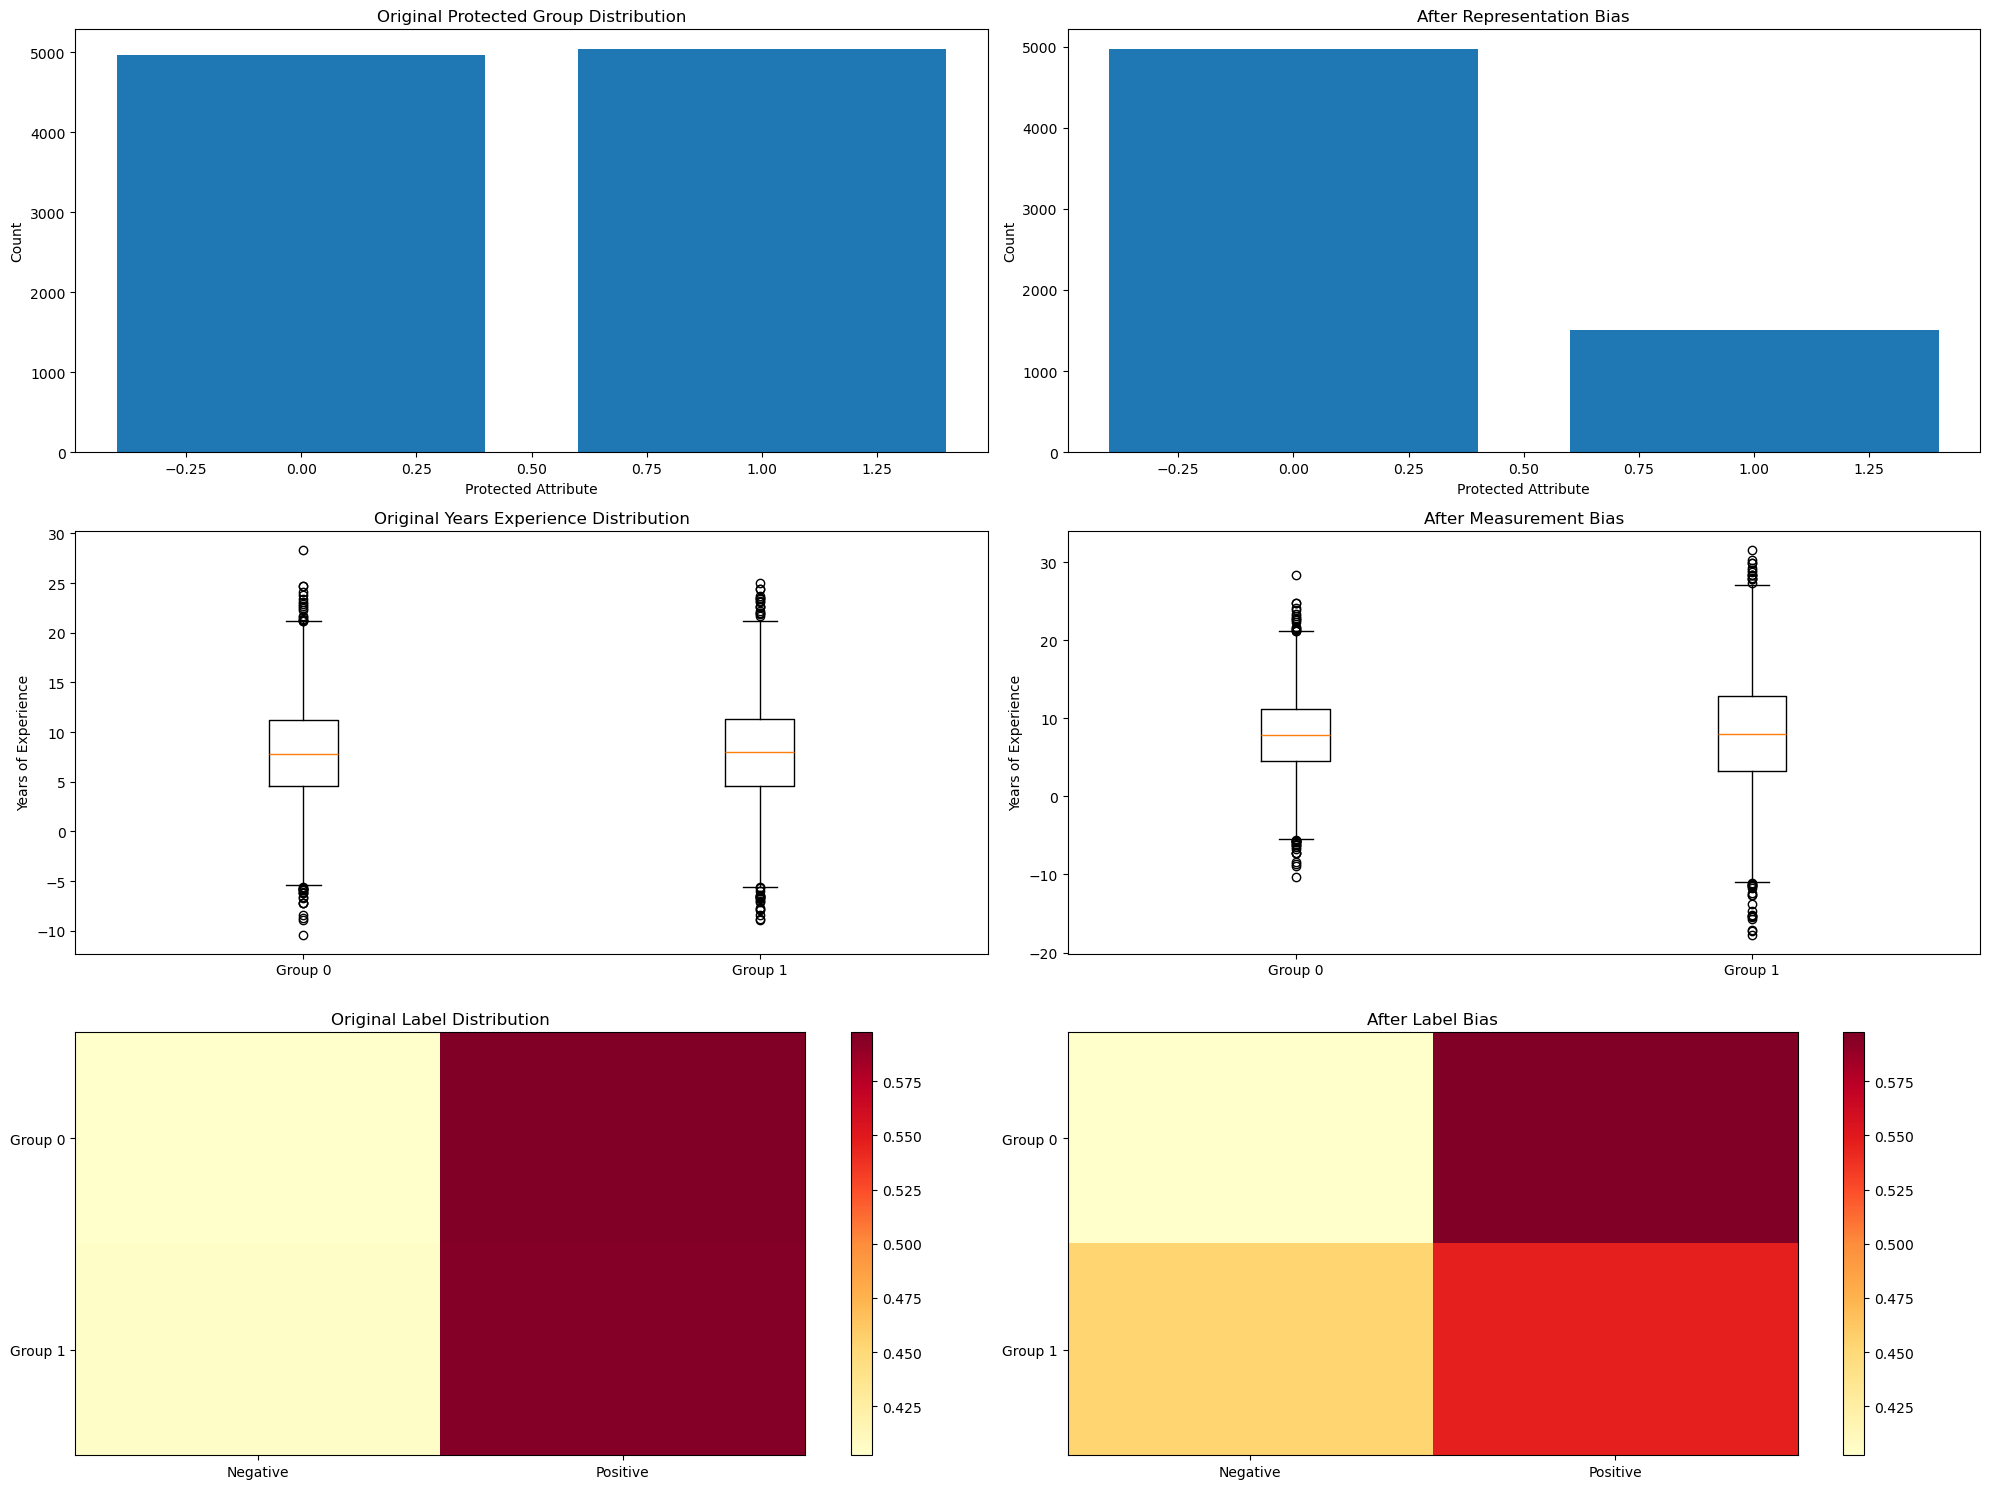

In [13]:
# Visualize the effects of different types of bias
plots = visualize_bias_effects(biased_datasets)
plots.show()